### Agentic RAG

In [4]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")
os.environ["LANGCHAIN_TRACING_V2"]="true"

In [5]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [6]:
urls=[
    "https://python.langchain.com/docs/tutorials/"]

docs=[WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessa

In [7]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)

doc_splits = text_splitter.split_documents(docs_list)

vectorstore = FAISS.from_documents(documents=doc_splits, embedding=HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5"))

retriever = vectorstore.as_retriever()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3607.42it/s]


In [8]:
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x00000206D56D0AD0>, search_kwargs={})

In [9]:
retriever.invoke("what is langchain")

[Document(id='d3920898-c39d-4847-9ede-6d7aab220d56', metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content="LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogP

In [11]:
from langchain_core.tools import create_retriever_tool
retriever_tool = create_retriever_tool( retriever, "search_documents",
    "Search the documents for information relevant to the user's question.")

### Langchain Blogs- Seperate Vector Store

In [12]:
langchain_urls=[
    "https://python.langchain.com/docs/tutorials/"
]

docs=[WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessa

In [14]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add alll these text to vectordb

vectorstorelangchain=FAISS.from_documents(
    documents=doc_splits,
    embedding=HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")
)


retrieverlangchain=vectorstorelangchain.as_retriever()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7367.00it/s]


In [16]:
from langchain_core.tools import create_retriever_tool

retriever_tool_langchain=create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [17]:
tools=[retriever_tool,retriever_tool_langchain]

### LangGraph Workflow

In [18]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, AnyMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage], add_messages]

In [20]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")
llm.invoke("Hi")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi". We need to respond appropriately. It\'s a casual greeting. Should be friendly. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 72, 'total_tokens': 116, 'completion_time': 0.091196529, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.00299391, 'prompt_tokens_details': None, 'queue_time': 0.314296921, 'total_time': 0.094190439}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_47082602e2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ffffe-d652-77f0-9593-60705e400907-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 44, 'total_tokens': 116, 'output_token_details': {'reasoning': 26}})

In [ ]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatGroq(model="openai/gpt-oss-120b")
    llm_with_tools = model.bind_tools(tools)
    reponse = llm_with_tools.invoke(messages)
    return {"messages": [reponse]}

In [23]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langchain_classic import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field

In [24]:
def grade_documents(state)->Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    class grade(BaseModel):
         """Binary score for relevance check."""

         binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    model = llm

    llm_with_tool = model.with_structured_output(grade)

    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    chain = prompt|llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"


In [25]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = ChatGroq(model="openai/gpt-oss-120b")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [26]:

def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="openai/gpt-oss-120b")
    response = model.invoke(msg)
    return {"messages": [response]}

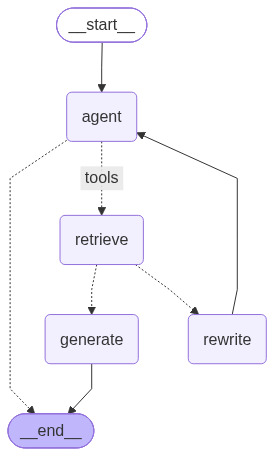

In [28]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)
retriever = ToolNode([retriever_tool, retriever_tool_langchain])
workflow.add_node("retrieve", retriever)
workflow.add_node("rewrite", rewrite)
workflow.add_node("generate", generate)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", tools_condition, {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },)

workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [29]:
graph.invoke({"messages":"What is Langgraph?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='98d231ce-8332-490c-9a8e-4416be8bde9d'),
  AIMessage(content='**LangGraph – a quick‑look**\n\n| Aspect | What it is | Why it matters |\n|--------|------------|----------------|\n| **Category** | Open‑source Python framework for building **state‑ful, graph‑structured** LLM (or generative AI) applications. | Lets you orchestrate many LLM calls, tools, and other services as a directed graph where each node can read/write a shared **state**. |\n| **Origin** | Part of the **LangChain ecosystem** (maintained by the same team that created LangChain). It builds on top of LangChain’s abstractions (\u200b`LLM`, `ChatModel`, `Tool`, `Retriever`, etc.) but adds a dedicated graph execution engine. | If you already use LangChain, you can drop‑in LangGraph with minimal changes; if you’re new, you get a higher‑level way to think about workflows. |\n| **Core idea** | **Nodes** = reusable “agents”, “t

In [30]:
graph.invoke({"messages":"What is Langchain?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='539232a4-1e79-461b-ab84-d80895f4b739'),
  AIMessage(content='**LangChain** is an open‑source framework that makes it easy to build applications powered by large language models (LLMs).  \nIt provides a collection of modular building blocks—**chains**, **agents**, **memory**, **data‑connectors**, and **evaluation tools**—that let developers stitch together LLM calls, external APIs, and custom logic without reinventing the wheel.\n\n### Core Concepts\n\n| Component | What it does | Typical use‑case |\n|-----------|--------------|-----------------|\n| **Chains** | Sequentially combine multiple “links” (LLM calls, prompts, data look‑ups, etc.) | Summarizing a document → extracting key entities → formatting a report |\n| **Agents** | Decide **what** action to take next based on LLM reasoning (e.g., “search the web”, “call a database”, “run Python code”) | Chatbot that can fetch up‑to‑dat

In [31]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='b62a95bf-8b12-4115-977e-245a2d09a76e'),
  AIMessage(content='**Machine learning (ML)** is a subfield of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to **learn from data** and improve their performance on a specific task without being explicitly programmed for every possible scenario.\n\n### Core Idea\n- **Learning from examples:** Instead of writing explicit rules, you feed the system a large collection of examples (data) and let it infer patterns, relationships, or rules.\n- **Prediction or decision‑making:** Once trained, the model can make predictions, classify new inputs, generate content, or take actions based on what it has learned.\n\n### How It Works (High‑level)\n1. **Data Collection:** Gather labeled (supervised) or unlabeled (unsupervised) data.\n2. **Feature Extraction (optional):** Transform raw 